# 🏋️ Task 1 — Notebook 2: Model Training

**Purpose:** Train one or more CNN models. Swap models by changing `MODEL_NAME`.
Results are saved separately per model in `outputs/<model_name>/`.

**Author:** [Your Name] | **GitHub:** [Your Repo URL]

---
### Notebooks in this project:
| Notebook | Purpose |
|----------|---------|
| `01_data_analysis.ipynb` | EDA |
| `02_train.ipynb` | ← **You are here** — Training |
| `03_evaluate.ipynb` | Evaluation & comparison |

## 0. Setup

In [ ]:
!pip install medmnist scikit-learn seaborn matplotlib torchvision --quiet

import os
REPO_URL  = 'https://github.com/YOUR_USERNAME/YOUR_REPO.git'  # ← UPDATE
REPO_NAME = 'YOUR_REPO'                                        # ← UPDATE

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}

os.chdir(REPO_NAME)
import sys; sys.path.insert(0, '.')
print('Ready. CWD:', os.getcwd())

In [1]:
import sys
print(sys.executable)

C:\Users\pro\.conda\envs\med_env\python.exe


In [1]:
import json, time, os
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt

# ── Import from our modules ────────────────────────────────────────────────
from data.dataset   import get_dataloaders, get_class_weights
from models.registry import get_model, list_models, get_model_name, count_parameters

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

print(f'\nAvailable models: {list_models()}')

Device: cuda
GPU: NVIDIA GeForce GTX 1080 Ti

Available models: ['efficientnet', 'resnet', 'custom_cnn', 'vit']


## 1. Configuration

**🔧 Change `MODEL_NAME` here to swap models:**
- `'vit'`         —  Vision Transformer 
- `'efficientnet'` — EfficientNet-B0 
- `'resnet'`       — ResNet-18
- `'custom_cnn'`  — Custom CNN from scratch

In [2]:
# ══════════════════════════════════════════════════════════
#   CHANGE THIS TO SWAP MODEL
MODEL_NAME = 'resnet'   # 'efficientnet' | 'resnet' | 'custom_cnn' |'vit'
# ══════════════════════════════════════════════════════════

# Hyperparameters
EPOCHS         = 100
BATCH_SIZE     = 64
LR             = 1e-3
WEIGHT_DECAY   = 1e-4
DROPOUT        = 0.4
UNFREEZE_EPOCH = 6      # Phase 2 starts here — unfreeze all layers
SEED           = 42

# Output dir is per-model
OUTPUT_DIR = f'outputs/{MODEL_NAME}'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Model:      {MODEL_NAME}')
print(f'Output dir: {OUTPUT_DIR}')

Model:      resnet
Output dir: outputs/resnet


## 2. Data

In [3]:
import numpy as np, random
def set_seed(seed):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(SEED)

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE, num_workers=2)

pos_weight, n_neg, n_pos = get_class_weights()
print(f'pos_weight = {pos_weight:.3f}  (used to down-weight majority class in loss)')

[Dataset] train=4708 | val=524 | test=624
[Dataset] classes=['normal', 'pneumonia'] | image_size=28×28
[Dataset] Normal=1214 (25.8%) | Pneumonia=3494 (74.2%) | pos_weight=0.347
pos_weight = 0.347  (used to down-weight majority class in loss)


## 3. Model

In [4]:
# ── Instantiate model from registry ───────────────────────────────────────
model      = get_model(MODEL_NAME, pretrained=True, dropout=DROPOUT).to(device)
model_name = get_model_name(model)
params     = count_parameters(model)

print(f'Model:       {model_name}')
print(f'Total:       {params["total"]:,}')
print(f'Trainable:   {params["trainable"]:,}  ({params["trainable"]/params["total"]*100:.1f}%)')
print(f'Frozen:      {params["frozen"]:,}')

# Test forward pass
with torch.no_grad():
    dummy = torch.randn(2, 1, 28, 28).to(device)
    out   = model(dummy)
print(f'Output shape: {out.shape}  (raw logit — apply sigmoid for probability)')

Model:       ResNet-18
Total:       11,177,025
Trainable:   11,167,489  (99.9%)
Frozen:      9,536
Output shape: torch.Size([2, 1])  (raw logit — apply sigmoid for probability)


## 4. Training

**Two-phase strategy:**
- **Phase 1 (epochs 1–5):** Only unfrozen layers train at `LR=1e-3`. Protects pretrained features.
- **Phase 2 (epoch 6+):** All layers unfreeze. `LR` drops 10×. Cosine annealing for smooth decay.

In [5]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=device))

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

def run_epoch(model, loader, training):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().to(device)
            logits = model(images)
            loss   = criterion(logits.squeeze(1), labels.squeeze(1))
            if training:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            preds = (torch.sigmoid(logits) >= 0.5).long().squeeze(1)
            total_loss += loss.item() * images.size(0)
            correct    += (preds == labels.squeeze(1).long()).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total

print('Optimizer & criterion ready.')

Optimizer & criterion ready.


In [6]:
history = {'model': MODEL_NAME, 'model_name': model_name,
           'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc    = 0.0
best_model_path = f'{OUTPUT_DIR}/best_model.pth'

for epoch in range(1, EPOCHS + 1):
    # ── Phase 2 unlock ────────────────────────────────────────────────────
    if epoch == UNFREEZE_EPOCH:
        model.unfreeze_all()
        optimizer = AdamW(model.parameters(), lr=LR * 0.1, weight_decay=WEIGHT_DECAY)
        scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - epoch, eta_min=1e-7)
        print(f'\n[Epoch {epoch}] ── Unfreezing all layers (LR={LR*0.1:.2e})')

    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, training=True)
    va_loss, va_acc = run_epoch(model, val_loader,   training=False)
    scheduler.step()
    lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss);   history['val_acc'].append(va_acc)
    history['lr'].append(lr)

    flag = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({'epoch': epoch, 'model_name': model_name,
                    'model_state_dict': model.state_dict(), 'val_acc': va_acc,
                    'model_key': MODEL_NAME}, best_model_path)
        flag = ' ← best'

    print(f'Epoch [{epoch:02d}/{EPOCHS}]  '
          f'Train loss={tr_loss:.4f} acc={tr_acc:.4f}  |  '
          f'Val loss={va_loss:.4f} acc={va_acc:.4f}  |  '
          f'LR={lr:.2e}  |  {time.time()-t0:.1f}s{flag}')

with open(f'{OUTPUT_DIR}/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f'\n✓ Training complete. Best val_acc = {best_val_acc:.4f}')
print(f'✓ Model saved to {best_model_path}')

Epoch [01/100]  Train loss=0.1168 acc=0.9058  |  Val loss=0.0552 acc=0.9676  |  LR=1.00e-03  |  29.6s ← best
Epoch [02/100]  Train loss=0.0746 acc=0.9433  |  Val loss=0.0479 acc=0.9637  |  LR=9.99e-04  |  30.0s
Epoch [03/100]  Train loss=0.0562 acc=0.9572  |  Val loss=0.0481 acc=0.9618  |  LR=9.98e-04  |  29.1s
Epoch [04/100]  Train loss=0.0550 acc=0.9598  |  Val loss=0.0718 acc=0.9122  |  LR=9.96e-04  |  29.8s
Epoch [05/100]  Train loss=0.0576 acc=0.9540  |  Val loss=0.0911 acc=0.9008  |  LR=9.94e-04  |  29.5s

[Epoch 6] ── Unfreezing all layers (LR=1.00e-04)
Epoch [06/100]  Train loss=0.0422 acc=0.9694  |  Val loss=0.0336 acc=0.9771  |  LR=1.00e-04  |  30.6s ← best
Epoch [07/100]  Train loss=0.0358 acc=0.9726  |  Val loss=0.0329 acc=0.9656  |  LR=9.99e-05  |  31.1s
Epoch [08/100]  Train loss=0.0356 acc=0.9760  |  Val loss=0.0313 acc=0.9733  |  LR=9.97e-05  |  30.2s
Epoch [09/100]  Train loss=0.0284 acc=0.9775  |  Val loss=0.0308 acc=0.9771  |  LR=9.96e-05  |  30.4s
Epoch [10/100]  Tr

## 5. Training Curves

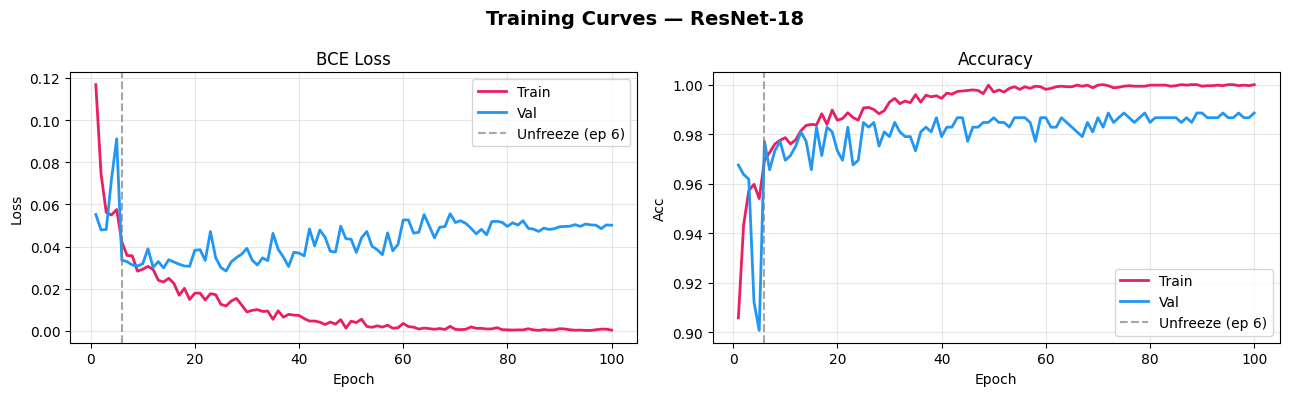

Next: Open 03_evaluate.ipynb to evaluate this model (and compare all models)


In [7]:
epochs_r = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_r, history['train_loss'], label='Train', color='#E91E63', lw=2)
axes[0].plot(epochs_r, history['val_loss'],   label='Val',   color='#2196F3', lw=2)
axes[0].axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.7,
               label=f'Unfreeze (ep {UNFREEZE_EPOCH})')
axes[0].set_title('BCE Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_r, history['train_acc'], label='Train', color='#E91E63', lw=2)
axes[1].plot(epochs_r, history['val_acc'],   label='Val',   color='#2196F3', lw=2)
axes[1].axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.7,
               label=f'Unfreeze (ep {UNFREEZE_EPOCH})')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Acc')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'Training Curves — {model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\rNext: Open 03_evaluate.ipynb to evaluate this model (and compare all models)')